# 03 — Stylised facts of Walmart (WMT): statistical tests and GJR-GARCH

In this notebook we test, for **Walmart (WMT)**, the six stylised facts required by the project brief, at the **daily, weekly and monthly** frequencies:

1. Little or no autocorrelation in returns;
2. Non-normal distribution with fat tails (especially at the daily frequency);
3. Asymmetry of the distribution (possible negative *skewness*);
4. Volatility *clustering* (absolute and squared returns);
5. Leverage effect (volatility reacts more to negative shocks than to positive ones);
6. Conditional non-normality (standardised residuals of a volatility model).

**SPY** (the ETF that tracks the S&P 500) is used as a benchmark for comparison.

**Decision rule:** 5% significance level → if the *p-value* < 0.05 we reject the null hypothesis (H0).
The brief tells us **not to assume** that all the facts hold — so, for each fact, we look at the numbers and decide.

Figures are saved in `../figures/` and tables in `../results/`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from arch import arch_model
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')   # hide library version warnings (they do not change the results)

plt.style.use('default')   # matplotlib's default style (DejaVu Sans font) -> the same charts on every computer
plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)

# Folders where we will save the figures and the tables
os.makedirs('../figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)

ALPHA = 0.05   # significance level used in all the tests

## 1. Load the log returns

The returns were computed in notebook `01` from the **adjusted** prices (*Adj Close*), which already account for dividends and *splits*
(for example, Walmart's 3-for-1 *split* in February 2024 does not show up as a fake -67% drop).

- **Daily:** $r_t = \ln(P_t) - \ln(P_{t-1})$
- **Weekly and monthly:** using the last price of each week (Friday) / of each month.

In [2]:
ret_d = pd.read_csv('data/daily_log_returns.csv', index_col=0, parse_dates=True)
ret_w = pd.read_csv('data/weekly_log_returns.csv', index_col=0, parse_dates=True)
ret_m = pd.read_csv('data/monthly_log_returns.csv', index_col=0, parse_dates=True)

# Dictionary with the 3 frequencies -> lets us use loops (for) instead of repeating the code 3 times
frequencies = {
    'Daily': ret_d,
    'Weekly': ret_w,
    'Monthly': ret_m,
}

# Number of periods in a year (to annualise)
periods_per_year = {'Daily': 252, 'Weekly': 52, 'Monthly': 12}

assets = ['WMT', 'SPY']   # WMT = chosen stock | SPY = market benchmark

for freq, table in frequencies.items():
    r = table['WMT'].dropna()
    print(f'{freq:8s}: {len(r):5d} observations, from {r.index.min().date()} to {r.index.max().date()}')

Daily   :  4202 observations, from 2010-01-05 to 2026-09-18
Weekly  :   871 observations, from 2010-01-15 to 2026-09-18
Monthly :   199 observations, from 2010-02-28 to 2026-08-31


**Check:** with **log** returns, the return of a month is equal to the sum of the daily returns in that month.
This confirms that the two ways of computing it (end-of-period price vs. sum of the daily returns) give the same result.

In [3]:
# Add up the daily returns within each month / week
monthly_sum = ret_d['WMT'].resample('ME').sum()
weekly_sum = ret_d['WMT'].resample('W-FRI').sum()

# Put them side by side and drop incomplete rows
comp_m = pd.DataFrame({'month_end_price': ret_m['WMT'], 'sum_of_daily': monthly_sum}).dropna()
comp_w = pd.DataFrame({'week_end_price': ret_w['WMT'], 'sum_of_daily': weekly_sum}).dropna()

print('Largest difference (monthly):', (comp_m['month_end_price'] - comp_m['sum_of_daily']).abs().max())
print('Largest difference (weekly): ', (comp_w['week_end_price'] - comp_w['sum_of_daily']).abs().max())

Largest difference (monthly): 1.1032841307212493e-15
Largest difference (weekly):  8.014422459012849e-16


## 2. Descriptive statistics (WMT and SPY, 3 frequencies)

The kurtosis shown is the **excess kurtosis** (kurtosis − 3): a normal distribution has a value of 0.

In [4]:
def descriptive_stats(r, n_periods):
    # Computes the descriptive statistics of a series of log returns
    r = r.dropna()
    return {
        'N': len(r),
        'Mean': r.mean(),
        'Std. dev.': r.std(),
        'Min': r.min(),
        'Max': r.max(),
        'Skewness': stats.skew(r),
        'Excess kurtosis': stats.kurtosis(r),          # fisher=True by default -> normal = 0
        'Ann. mean': r.mean() * n_periods,               # annualised mean
        'Ann. volatility': r.std() * np.sqrt(n_periods)  # annualised volatility (square-root-of-time rule)
    }


rows = []
for asset in assets:
    for freq, table in frequencies.items():
        row = descriptive_stats(table[asset], periods_per_year[freq])
        row['Asset'] = asset
        row['Frequency'] = freq
        rows.append(row)

tab_descriptive = pd.DataFrame(rows).set_index(['Asset', 'Frequency'])
display(tab_descriptive.round(4))

N    Mean  Std. dev.     Min     Max  Skewness  Excess kurtosis  Ann. mean  Ann. volatility
Asset Frequency                                                                                                
WMT   Daily      4202  0.0005     0.0126 -0.1208  0.1107   -0.2546          14.3211     0.1268           0.1999
      Weekly      871  0.0024     0.0273 -0.2167  0.1093   -0.8532           6.6738     0.1273           0.1970
      Monthly     199  0.0106     0.0517 -0.1698  0.1378   -0.3603           0.8379     0.1274           0.1791
SPY   Daily      4202  0.0005     0.0108 -0.1159  0.0999   -0.5549          12.4025     0.1320           0.1709
      Weekly      871  0.0025     0.0224 -0.1572  0.1141   -0.7400           5.8279     0.1307           0.1617
      Monthly     199  0.0114     0.0413 -0.1334  0.1195   -0.4909           0.6703     0.1362           0.1432

## 3. Fact 1 — Little or no autocorrelation in returns

- **ACF plot:** bars inside the blue band (95%) → autocorrelation is not significant.
- **Ljung-Box test:** H0 = "no autocorrelation up to lag *m*". *p-value* < 0.05 → we reject H0.

Note: with thousands of daily observations, even tiny autocorrelations become "significant".
That is why we also look at the **size** of the autocorrelations.

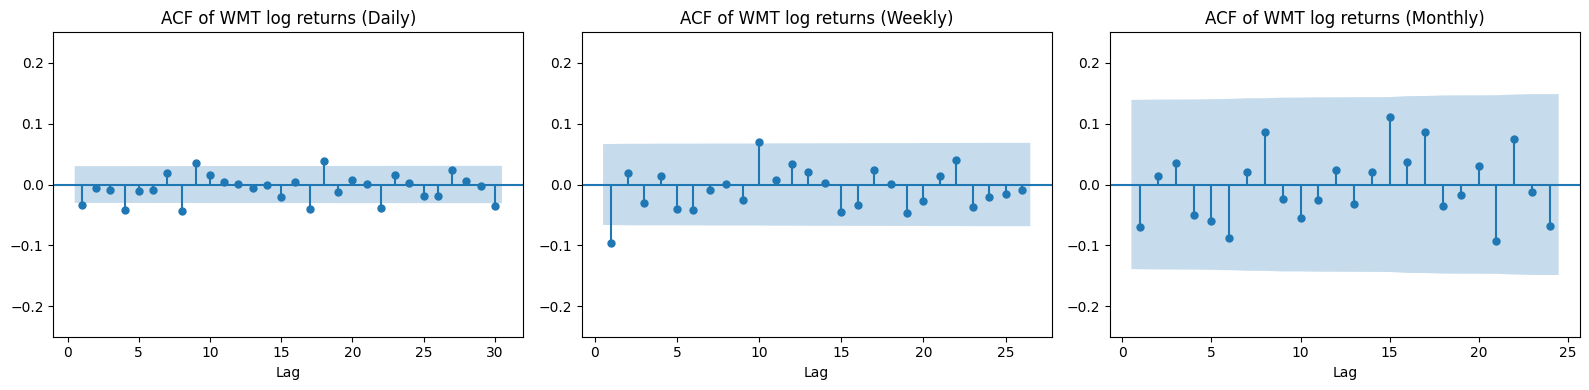

In [5]:
# Number of lags to show in the plots and to use in the tests, for each frequency
plot_lags = {'Daily': 30, 'Weekly': 26, 'Monthly': 24}
test_lags = {'Daily': [5, 10, 20], 'Weekly': [4, 8, 12], 'Monthly': [3, 6, 12]}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, (freq, table) in enumerate(frequencies.items()):
    plot_acf(table['WMT'].dropna(), lags=plot_lags[freq], ax=axes[i], zero=False, alpha=0.05)
    axes[i].set_title(f'ACF of WMT log returns ({freq})')
    axes[i].set_xlabel('Lag')
    axes[i].set_ylim(-0.25, 0.25)
plt.tight_layout()
plt.savefig('../figures/03_acf_returns_wmt.png', dpi=150)
plt.show()

In [6]:
def ljung_box_table(series, lags, asset, freq, series_name):
    # Runs the Ljung-Box test for several lags and returns a list of rows (dictionaries)
    result = acorr_ljungbox(series.dropna(), lags=lags)
    rows = []
    for lag in lags:
        rows.append({
            'Asset': asset,
            'Frequency': freq,
            'Series': series_name,
            'Lag': lag,
            'Q stat': result.loc[lag, 'lb_stat'],
            'p-value': result.loc[lag, 'lb_pvalue'],
        })
    return rows


rows = []
for asset in assets:
    for freq, table in frequencies.items():
        rows += ljung_box_table(table[asset], test_lags[freq], asset, freq, 'r')

tab_lb_returns = pd.DataFrame(rows)
tab_lb_returns['Reject H0 (5%)'] = tab_lb_returns['p-value'] < ALPHA
display(tab_lb_returns.round(4))

,Asset,Frequency,Series,Lag,Q stat,p-value,Reject H0 (5%)
0,WMT,Daily,r,5,13.1086,0.0224,True
1,WMT,Daily,r,10,29.2625,0.0011,True
2,WMT,Daily,r,20,45.1819,0.0010,True
3,WMT,Weekly,r,4,9.2443,0.0553,False
4,WMT,Weekly,r,8,12.2448,0.1406,False
5,WMT,Weekly,r,12,18.1953,0.1099,False
6,WMT,Monthly,r,3,1.2870,0.7322,False
7,WMT,Monthly,r,6,4.1358,0.6583,False
8,WMT,Monthly,r,12,6.7871,0.8714,False
9,SPY,Daily,r,5,70.9275,0.0000,True


In [7]:
# How LARGE are the autocorrelations (lags 1 to 5)?
rows = []
for asset in assets:
    for freq, table in frequencies.items():
        r = table[asset].dropna()
        values = acf(r, nlags=5)
        row = {'Asset': asset, 'Frequency': freq}
        for lag in range(1, 6):
            row[f'lag {lag}'] = values[lag]
        row['95% band (±1.96/√N)'] = 1.96 / np.sqrt(len(r))
        rows.append(row)

tab_acf = pd.DataFrame(rows).set_index(['Asset', 'Frequency'])
display(tab_acf.round(4))

lag 1   lag 2   lag 3   lag 4   lag 5  95% band (±1.96/√N)
Asset Frequency                                                             
WMT   Daily     -0.0344 -0.0061 -0.0087 -0.0413 -0.0106               0.0302
      Weekly    -0.0953  0.0193 -0.0301  0.0143 -0.0395               0.0664
      Monthly   -0.0698  0.0139  0.0360 -0.0503 -0.0593               0.1389
SPY   Daily     -0.1003  0.0615 -0.0376 -0.0401  0.0014               0.0302
      Weekly    -0.0889  0.0365 -0.0149 -0.0563 -0.0641               0.0664
      Monthly   -0.1253 -0.1169  0.0271 -0.0580  0.0009               0.1389

**Reading the results (Fact 1):**

- **Monthly and weekly (WMT):** the Ljung-Box test **does not reject** H0 → no evidence of autocorrelation. The fact holds.
- **Daily (WMT):** the Ljung-Box test rejects H0, but the autocorrelations are very small (|ρ| < 0.05; lags 1 to 5 are all negative).
  With ~4,200 observations the 95% band is only ±0.03, so tiny values become "significant".
  Economically, knowing today's return hardly helps to predict tomorrow's.
- In addition, the Ljung-Box test assumes constant variance; with volatility *clustering* (Fact 4) it tends to reject too often.
  In section 8 we repeat the test on the **standardised residuals of the GARCH** and there the autocorrelation is no longer significant.
- **SPY** shows stronger negative daily autocorrelation (lag 1 ≈ −0.1), typical of indices in periods of stress (reversal effects).

**Conclusion:** the fact is supported in practice for WMT — the autocorrelation in the level of returns is small or non-existent.

## 4. Fact 2 — Non-normal distribution and fat tails

- **Q-Q plot:** if returns were normal, the points would lie on the red line.
- **Jarque-Bera:** H0 = normality (it uses the skewness and the kurtosis).
- **Kurtosis test (`kurtosistest`):** H0 = kurtosis equal to that of the normal.
- **% of observations more than 3 standard deviations from the mean:** under a normal it would be only 0.27%.

(The histograms with the normal curve for the 3 frequencies are already in notebook `02`.)

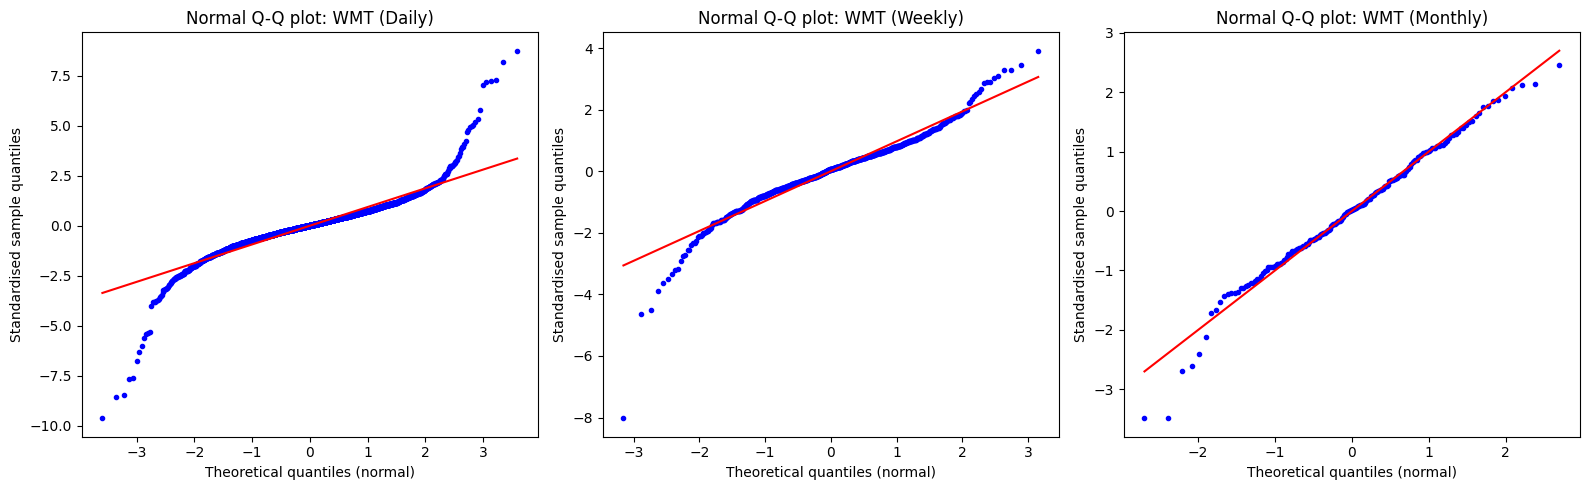

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (freq, table) in enumerate(frequencies.items()):
    r = table['WMT'].dropna()
    r_standardised = (r - r.mean()) / r.std()      # mean 0 and standard deviation 1
    stats.probplot(r_standardised, dist='norm', plot=axes[i])
    axes[i].get_lines()[0].set_markersize(3)
    axes[i].get_lines()[1].set_color('red')
    axes[i].set_title(f'Normal Q-Q plot: WMT ({freq})')
    axes[i].set_xlabel('Theoretical quantiles (normal)')
    axes[i].set_ylabel('Standardised sample quantiles')
plt.tight_layout()
plt.savefig('../figures/03_qqplot_normal_wmt_3freq.png', dpi=150)
plt.show()

In [9]:
prob_normal_3sd = 2 * stats.norm.sf(3)   # P(|Z| > 3) under a normal = 0.27%

rows = []
for asset in assets:
    for freq, table in frequencies.items():
        r = table[asset].dropna()
        z = (r - r.mean()) / r.std()
        jb = stats.jarque_bera(r)
        kurtosis_test = stats.kurtosistest(r)
        rows.append({
            'Asset': asset,
            'Frequency': freq,
            'Excess kurtosis': stats.kurtosis(r),
            'Kurtosis test p-value': kurtosis_test.pvalue,
            'Jarque-Bera': jb.statistic,
            'JB p-value': jb.pvalue,
            '% |z|>3 (data)': 100 * (z.abs() > 3).mean(),
            '% |z|>3 (normal)': 100 * prob_normal_3sd,
        })

tab_normality = pd.DataFrame(rows).set_index(['Asset', 'Frequency'])
display(tab_normality.round(4))

Excess kurtosis  Kurtosis test p-value  Jarque-Bera  JB p-value  % |z|>3 (data)  % |z|>3 (normal)
Asset Frequency                                                                                                   
WMT   Daily              14.3211                 0.0000   35953.8399      0.0000          1.3803              0.27
      Weekly              6.6738                 0.0000    1722.0798      0.0000          1.7222              0.27
      Monthly             0.8379                 0.0358      10.1262      0.0063          1.0050              0.27
SPY   Daily              12.4025                 0.0000   27147.1993      0.0000          1.4279              0.27
      Weekly              5.8279                 0.0000    1312.1190      0.0000          1.3777              0.27
      Monthly             0.6703                 0.0708      11.7175      0.0029          0.5025              0.27

**Reading the results (Fact 2):**

- **Daily:** very high excess kurtosis (≈14) and Jarque-Bera with *p-value* ≈ 0 → normality is clearly rejected.
  There are about 5 times more days with moves beyond 3 standard deviations than the normal predicts. The Q-Q plot "bends" in both tails.
- **Weekly:** the tails are still fat (excess kurtosis ≈ 7).
- **Monthly:** the excess kurtosis falls to values close to 1 → the distribution gets closer to the normal when we aggregate
  (an effect of the Central Limit Theorem), although Jarque-Bera still rejects at 5%.

**Conclusion:** the fact is supported and is **strongest at the daily frequency**, as the brief suggests.

## 5. Fact 3 — Asymmetry (negative skewness?)

- **Skewness < 0** → the left tail (losses) is longer.
- **Skewness test (`skewtest`):** H0 = skewness equal to 0. **Caution:** this test assumes that the data have normal
  tails. With fat tails (Fact 2: excess kurtosis ≈ 14 for daily returns) it rejects H0 too often,
  even when the distribution is symmetric. That is why we show its *p-value* but do **not** use it to decide.
- **Bootstrap (the test we use to decide):** we resample the returns with replacement 2000 times and compute the skewness
  of each sample. This gives a 95% confidence interval and the proportion of samples with skewness ≥ 0
  (= one-sided *p-value* for "skewness < 0"). **We decide with this *p-value*: if it is < 0.05, the negative skewness is significant.**
  Note: a one-sided test at 5% corresponds to a 90% interval, so the (two-sided) 95% interval may slightly touch
  0 even when *p* < 0.05 — in that case the result is significant, but "borderline".
  (Limitation: this simple bootstrap resamples individual days and ignores volatility clustering.)
- We also count how many returns fall below −3σ and above +3σ, and we compare the 1% and 99% quantiles.

In [10]:
np.random.seed(2026)      # seed -> the bootstrap always gives the same result
N_BOOTSTRAP = 2000

rows = []
for asset in assets:
    for freq, table in frequencies.items():
        r = table[asset].dropna()
        z = (r - r.mean()) / r.std()
        skewness_test = stats.skewtest(r)

        # Bootstrap: resample the returns (with replacement) and recompute the skewness many times
        bootstrap_skews = []
        for i in range(N_BOOTSTRAP):
            sample = np.random.choice(r.values, size=len(r), replace=True)
            bootstrap_skews.append(stats.skew(sample))
        bootstrap_skews = np.array(bootstrap_skews)

        rows.append({
            'Asset': asset,
            'Frequency': freq,
            'Skewness': stats.skew(r),
            'Skewtest p (assumes normal tails)': skewness_test.pvalue,
            'Bootstrap 95% CI low': np.percentile(bootstrap_skews, 2.5),
            'Bootstrap 95% CI high': np.percentile(bootstrap_skews, 97.5),
            'Bootstrap p (skew >= 0)': (bootstrap_skews >= 0).mean(),
            'N below -3σ': (z < -3).sum(),
            'N above +3σ': (z > 3).sum(),
            'Quantile 1%': r.quantile(0.01),
            'Quantile 99%': r.quantile(0.99),
        })

tab_skewness = pd.DataFrame(rows).set_index(['Asset', 'Frequency'])
display(tab_skewness.round(4))

Skewness  Skewtest p (assumes normal tails)  Bootstrap 95% CI low  Bootstrap 95% CI high  Bootstrap p (skew >= 0)  N below -3σ  N above +3σ  Quantile 1%  Quantile 99%
Asset Frequency                                                                                                                                                                        
WMT   Daily       -0.2546                             0.0000               -1.1079                 0.6029                   0.2725           30           28      -0.0325        0.0317
      Weekly      -0.8532                             0.0000               -1.7681                 0.0028                   0.0265            9            6      -0.0795        0.0767
      Monthly     -0.3603                             0.0367               -0.7556                 0.1454                   0.0830            2            0      -0.1297        0.1208
SPY   Daily       -0.5549                             0.0000               -1.4042                 0.2772                   0.1130           39           21      -0.0308        0.0261
      Weekly      -0.7400                             0.0000               -1.5105                 0.0145                   0.0285            8            4      -0.0605        0.0569
      Monthly     -0.4909                             0.0053               -0.8507                -0.1117                   0.0050            1            0      -0.0923        0.1033

**Reading the results (Fact 3):**

- The skewness of WMT is **negative at all three frequencies**, but it is only statistically significant at the **weekly** frequency, and only just
  (bootstrap: one-sided *p* ≈ 0.03 < 0.05; the 95% interval goes from ≈ −1.77 to ≈ +0.003, i.e. it touches 0 → borderline evidence).
- **Daily:** skewness ≈ −0.25, but the bootstrap interval is very wide (≈ −1.1 to +0.6) and includes 0 → **not significant**.
  The value depends on a few extreme days (large falls on quarterly earnings days). The 1% and 99% quantiles are almost
  symmetric and the number of days below −3σ (30) is almost equal to the number above +3σ (28): the "body" of the distribution is symmetric.
  The `skewtest` gives *p* ≈ 0, but that is a false alarm caused by the fat tails.
- **Monthly:** skewness ≈ −0.36, bootstrap *p* ≈ 0.08 → weak evidence, not significant at 5%.
- **SPY:** negative skewness at all three frequencies, significant at the monthly frequency and, borderline, at the weekly one. At the daily and monthly
  frequencies it is more negative than that of WMT; at the weekly frequency WMT's is more negative.

**Conclusion:** the skewness is always negative, but there is (borderline) statistical evidence only at the weekly frequency.
For WMT (a defensive stock) the negative asymmetry is **weak** — the fact is only partially supported.

## 6. Fact 4 — Volatility clustering

If volatility clusters in time, the **absolute returns |r|** and the **squared returns r²** are autocorrelated
(turbulent days are followed by turbulent days), even if the returns *r* themselves are not.

- Plot of the returns + 21-day rolling volatility (≈ 1 month);
- ACF of |r| and r² at the 3 frequencies;
- Ljung-Box test on |r| and r² and Engle's **ARCH-LM** test (H0 = no ARCH effects, i.e. constant variance).

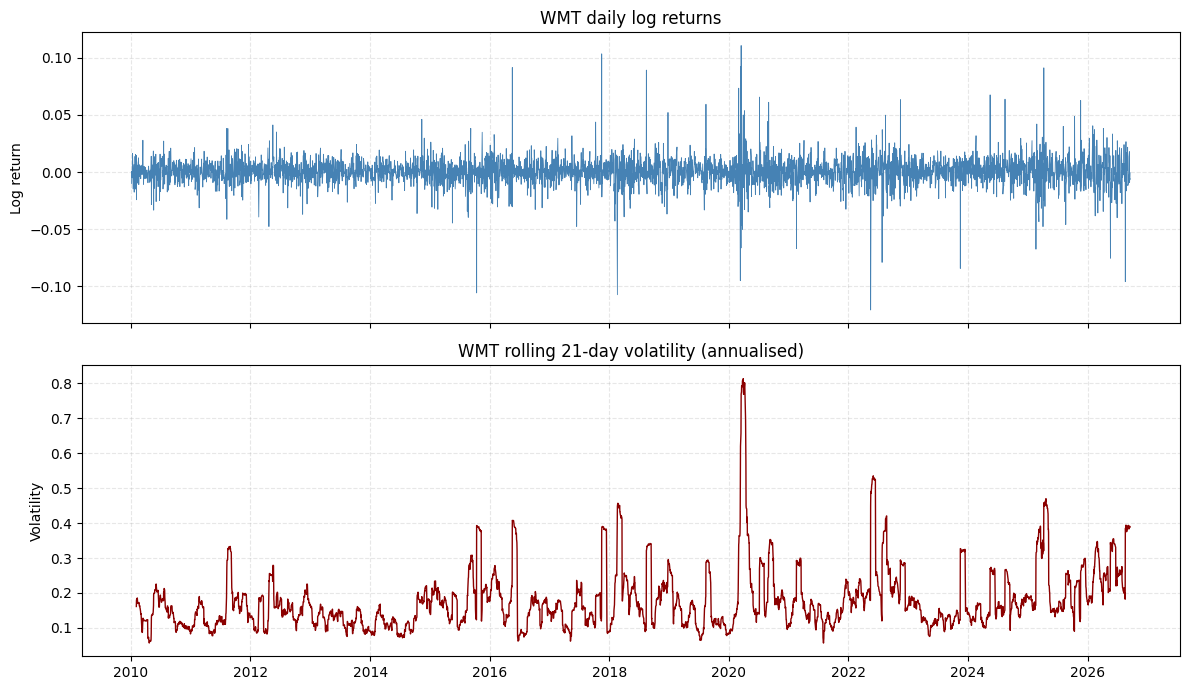

In [11]:
r_d = ret_d['WMT'].dropna()
rolling_vol = r_d.rolling(21).std() * np.sqrt(252)    # 21-day volatility, annualised

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(r_d.index, r_d, linewidth=0.6, color='steelblue')
axes[0].set_title('WMT daily log returns')
axes[0].set_ylabel('Log return')
axes[0].grid(True, linestyle='--', alpha=0.3)

axes[1].plot(rolling_vol.index, rolling_vol, linewidth=1, color='darkred')
axes[1].set_title('WMT rolling 21-day volatility (annualised)')
axes[1].set_ylabel('Volatility')
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/03_rolling_volatility_wmt.png', dpi=150)
plt.show()

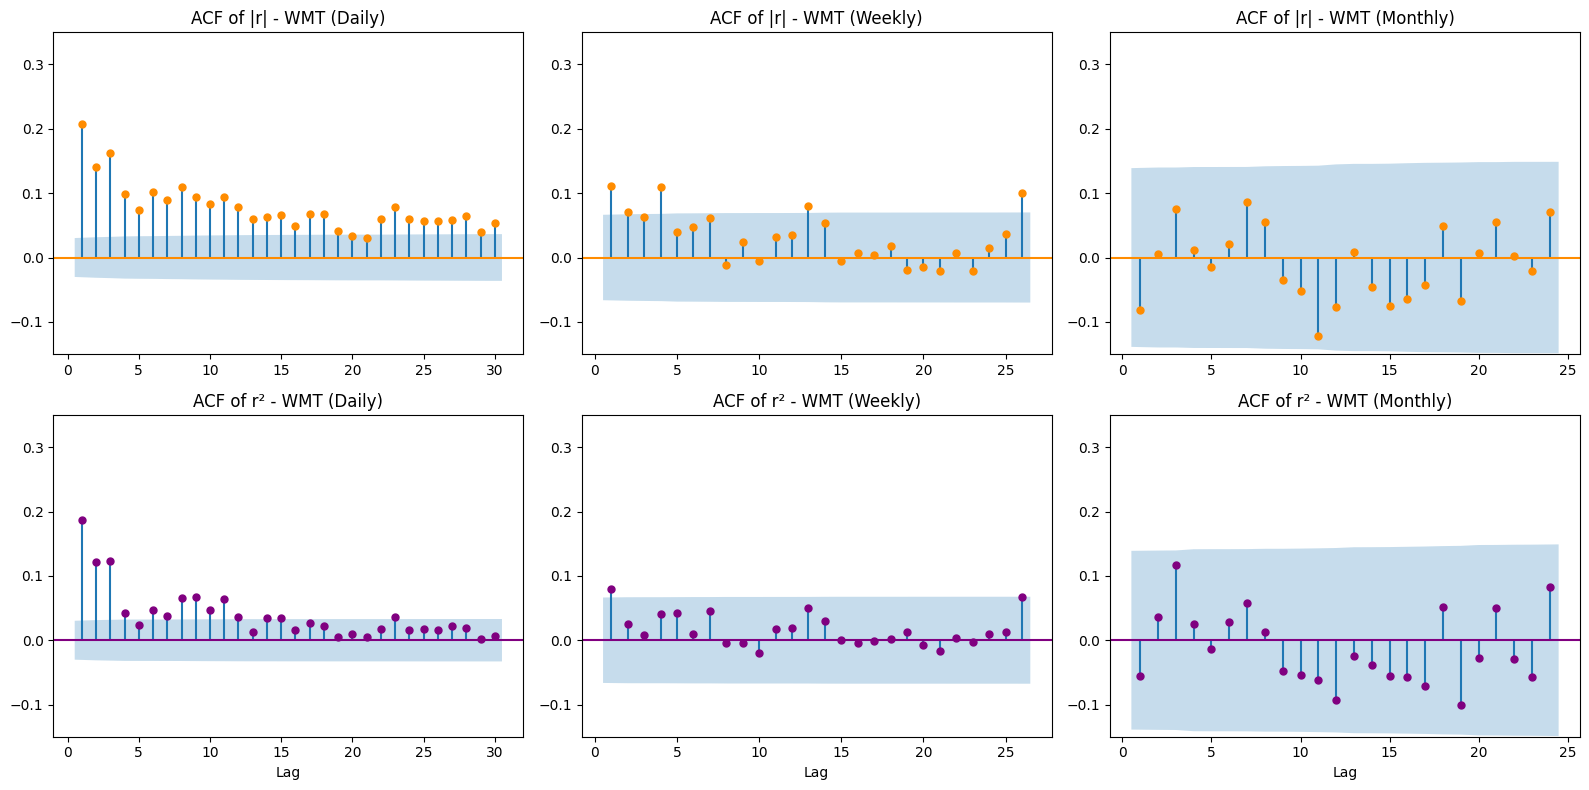

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for j, (freq, table) in enumerate(frequencies.items()):
    r = table['WMT'].dropna()

    # Top row: absolute returns
    plot_acf(r.abs(), lags=plot_lags[freq], ax=axes[0, j], zero=False, color='darkorange')
    axes[0, j].set_title(f'ACF of |r| - WMT ({freq})')
    axes[0, j].set_ylim(-0.15, 0.35)

    # Bottom row: squared returns
    plot_acf(r ** 2, lags=plot_lags[freq], ax=axes[1, j], zero=False, color='purple')
    axes[1, j].set_title(f'ACF of r² - WMT ({freq})')
    axes[1, j].set_ylim(-0.15, 0.35)
    axes[1, j].set_xlabel('Lag')

plt.tight_layout()
plt.savefig('../figures/03_acf_abs_squared_wmt.png', dpi=150)
plt.show()

In [13]:
rows = []
for asset in assets:
    for freq, table in frequencies.items():
        r = table[asset].dropna()
        lag = test_lags[freq][1]      # middle lag: 10 (daily), 8 (weekly), 6 (monthly)

        lb_abs = acorr_ljungbox(r.abs(), lags=[lag])
        lb_sq = acorr_ljungbox(r ** 2, lags=[lag])
        arch_test = het_arch(r - r.mean(), nlags=lag)   # returns (LM statistic, p-value, F, p-value of the F)

        rows.append({
            'Asset': asset,
            'Frequency': freq,
            'Lag': lag,
            'LB |r| p-value': lb_abs['lb_pvalue'].iloc[0],
            'LB r² p-value': lb_sq['lb_pvalue'].iloc[0],
            'ARCH-LM stat': arch_test[0],
            'ARCH-LM p-value': arch_test[1],
        })

tab_clustering = pd.DataFrame(rows).set_index(['Asset', 'Frequency'])
display(tab_clustering.round(4))

Lag  LB |r| p-value  LB r² p-value  ARCH-LM stat  ARCH-LM p-value
Asset Frequency                                                                   
WMT   Daily       10          0.0000         0.0000      235.8985           0.0000
      Weekly       8          0.0000         0.1880        8.9008           0.3507
      Monthly      6          0.8478         0.6722        3.3293           0.7665
SPY   Daily       10          0.0000         0.0000     1214.4835           0.0000
      Weekly       8          0.0000         0.0000      248.4325           0.0000
      Monthly      6          0.0053         0.0006       28.1544           0.0001

**Reading the results (Fact 4):**

- **Daily:** the ACFs of |r| and r² are positive and significant for many lags and decay slowly;
  Ljung-Box and ARCH-LM reject H0 with *p-values* ≈ 0 → **strong volatility clustering**.
  The plot shows it clearly: calm periods alternate with turbulent ones (e.g. March 2020).
- **Weekly:** weaker evidence — significant for |r| but not for r² nor in the ARCH-LM test.
- **Monthly:** no evidence for WMT (the *p-values* are above 0.05). SPY, on the other hand, keeps clustering even at the monthly frequency.

**Conclusion:** the fact is supported at the daily frequency; it weakens as we aggregate the returns (for WMT it disappears at the monthly frequency).

## 7. Fact 5 — Leverage effect (asymmetric response of volatility)

**7.1 Simple test:** correlation between today's return $r_t$ and the size of the return *k* days ahead $|r_{t+k}|$.
If it is **negative**, then falls today are associated with more volatility in the future → leverage effect.

**7.2 GJR-GARCH(1,1) model:**

$$\sigma_t^2 = \omega + \left(\alpha + \gamma \cdot I_{\{\varepsilon_{t-1}<0\}}\right)\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2$$

- $I_{\{\varepsilon_{t-1}<0\}}$ equals 1 if yesterday's shock was negative and 0 otherwise;
- **γ > 0 and significant** → negative shocks increase volatility more than positive shocks of the same size.

We estimate the model with **normal** and **Student-t** innovations (the latter allows for fat tails).

,WMT,SPY
k (days ahead),,
1,-0.0731,-0.1174
2,0.0008,-0.1511
3,-0.0251,-0.1072
4,-0.0427,-0.1651
5,0.0068,-0.0712
6,-0.0133,-0.1240
7,-0.0156,-0.0500
8,-0.0140,-0.0739
9,-0.0015,-0.0522


Approximate 95% band: ±0.0302


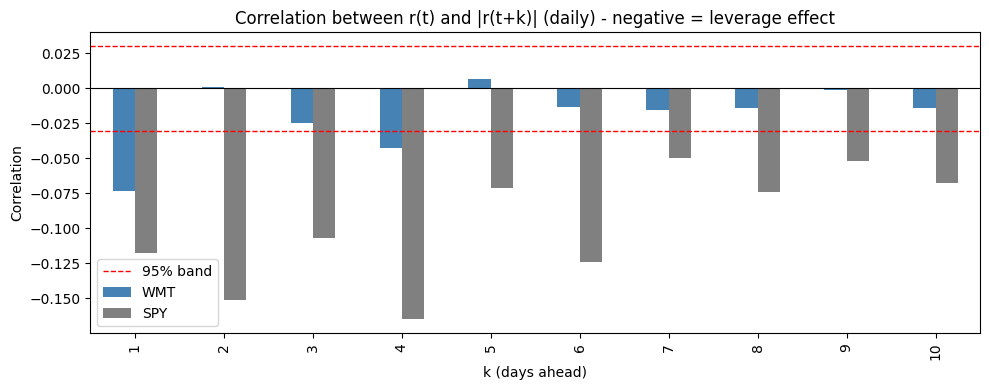

In [14]:
rows = []
for k in range(1, 11):
    row = {'k (days ahead)': k}
    for asset in assets:
        r = ret_d[asset].dropna()
        row[asset] = r.corr(r.shift(-k).abs())     # corr( r_t , |r_{t+k}| )
    rows.append(row)

tab_leverage_simple = pd.DataFrame(rows).set_index('k (days ahead)')
band = 1.96 / np.sqrt(len(ret_d['WMT'].dropna()))
display(tab_leverage_simple.round(4))
print(f'Approximate 95% band: ±{band:.4f}')

# Side-by-side bar chart
ax = tab_leverage_simple.plot(kind='bar', figsize=(10, 4), color=['steelblue', 'grey'])
ax.axhline(band, color='red', linestyle='--', linewidth=1)
ax.axhline(-band, color='red', linestyle='--', linewidth=1, label='95% band')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Correlation between r(t) and |r(t+k)| (daily) - negative = leverage effect')
ax.set_xlabel('k (days ahead)')
ax.set_ylabel('Correlation')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/03_leverage_correlation.png', dpi=150)
plt.show()

In [15]:
def fit_gjr(r, distribution):
    # GJR-GARCH(1,1) with a constant mean.
    # We multiply the returns by 100 (so they are in %) because the optimiser of the 'arch' library
    # works better with numbers on that scale.
    model = arch_model(100 * r.dropna(), mean='Constant', vol='GARCH', p=1, o=1, q=1, dist=distribution)
    result = model.fit(disp='off')
    if result.convergence_flag != 0:
        # The warnings are hidden at the top of the notebook, so we print this one ourselves
        print(f'WARNING: the GJR-GARCH fit ({r.name}, {distribution}) did not converge - do not trust its estimates')
    return result


# We store all the models in a dictionary with key (asset, frequency, distribution)
models = {}
for asset in assets:
    for freq, table in frequencies.items():
        for distribution in ['normal', 't']:
            models[(asset, freq, distribution)] = fit_gjr(table[asset], distribution)

# Table with the most important parameters
rows = []
for (asset, freq, distribution), res in models.items():
    p = res.params
    rows.append({
        'Asset': asset,
        'Frequency': freq,
        'Innovations': distribution,
        'omega': p['omega'],
        'alpha': p['alpha[1]'],
        'gamma': p['gamma[1]'],
        'gamma p-value': res.pvalues['gamma[1]'],
        'beta': p['beta[1]'],
        'persistence (α+γ/2+β)': p['alpha[1]'] + p['gamma[1]'] / 2 + p['beta[1]'],
        'nu (t d.o.f.)': p['nu'] if distribution == 't' else np.nan,
        'Log-lik.': res.loglikelihood,
        'AIC': res.aic,
        'BIC': res.bic,
    })

tab_gjr = pd.DataFrame(rows).set_index(['Asset', 'Frequency', 'Innovations'])
display(tab_gjr.round(4))

omega   alpha   gamma  gamma p-value    beta  persistence (α+γ/2+β)  nu (t d.o.f.)   Log-lik.         AIC         BIC
Asset Frequency Innovations                                                                                                                        
WMT   Daily     normal       0.1425  0.0394  0.0811         0.2022  0.8309                 0.9108            NaN -6685.1872  13380.3744  13412.0910
                t            0.1190  0.0612  0.0706         0.0055  0.8222                 0.9188         3.9306 -6155.8146  12323.6293  12361.6892
      Weekly    normal       0.0226  0.0000 -0.0000         1.0000  0.9982                 0.9982            NaN -2085.2775   4180.5550   4204.4032
                t            0.3158  0.0451  0.0010         0.9788  0.9151                 0.9608         4.1228 -2025.0373   4062.0747   4090.6925
      Monthly   normal       3.0545  0.0807 -0.0807         0.2762  0.8493                 0.8897            NaN  -607.2270   1224.4540   1240.9205
                t            0.0872  0.0000  0.0000         1.0000  1.0000                 1.0000        12.3480  -605.2993   1222.5985   1242.3583
SPY   Daily     normal       0.0380  0.0156  0.2343         0.0000  0.8279                 0.9606            NaN -5309.6837  10629.3673  10661.0839
                t            0.0294  0.0000  0.2805         0.0000  0.8332                 0.9734         5.8235 -5176.5349  10365.0698  10403.1297
      Weekly    normal       0.4712  0.0094  0.4944         0.0000  0.6615                 0.9181            NaN -1796.1515   3602.3030   3626.1512
                t            0.4259  0.0000  0.4542         0.0000  0.6823                 0.9094         8.1342 -1778.7642   3569.5285   3598.1463
      Monthly   normal       4.5371  0.0000  0.5184         0.0131  0.4593                 0.7185            NaN  -545.8784   1101.7568   1118.2233
                t            4.4928  0.0000  0.5710         0.5831  0.4392                 0.7247        14.3098  -545.4933   1102.9866   1122.7464

We show the full summary of the WMT daily model with Student-t innovations (the chosen model, because it has the lowest AIC):

In [16]:
print(models[('WMT', 'Daily', 't')].summary())

                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                          WMT   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -6155.81
Distribution:      Standardized Student's t   AIC:                           12323.6
Method:                  Maximum Likelihood   BIC:                           12361.7
                                              No. Observations:                 4202
Date:                      Thu, Oct 08 2026   Df Residuals:                     4201
Time:                              13:48:05   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

**News impact curve:** shows how much tomorrow's variance increases after a shock of size ε today.
If the curve is steeper on the left-hand side (negative shocks), there is a leverage effect.

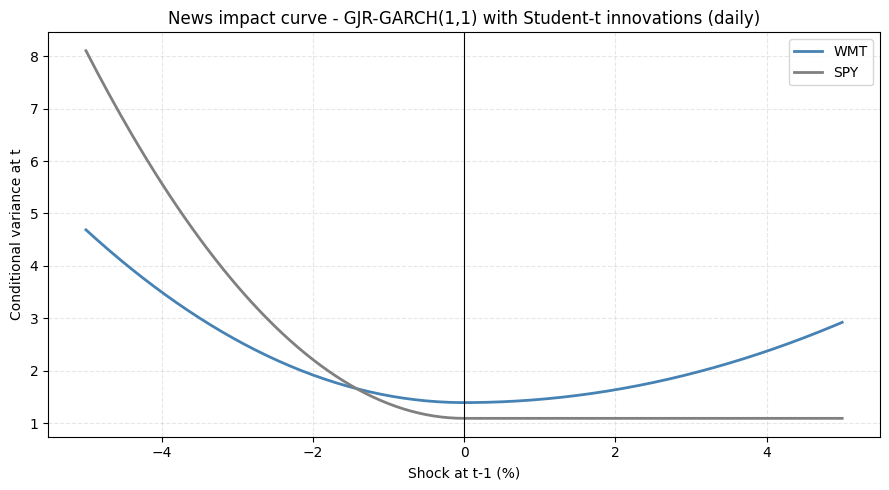

In [17]:
shocks = np.linspace(-5, 5, 201)          # shocks from -5% to +5%

plt.figure(figsize=(9, 5))
for asset, colour in zip(assets, ['steelblue', 'grey']):
    res = models[(asset, 'Daily', 't')]
    p = res.params
    mean_variance = (res.conditional_volatility ** 2).mean()   # "normal" level of the variance

    # Indicator: 1 if the shock is negative, 0 if it is positive
    negative = (shocks < 0).astype(int)
    new_variance = p['omega'] + (p['alpha[1]'] + p['gamma[1]'] * negative) * shocks ** 2 + p['beta[1]'] * mean_variance
    plt.plot(shocks, new_variance, label=asset, color=colour, linewidth=2)

plt.axvline(0, color='black', linewidth=0.8)
plt.title('News impact curve - GJR-GARCH(1,1) with Student-t innovations (daily)')
plt.xlabel('Shock at t-1 (%)')
plt.ylabel('Conditional variance at t')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/03_news_impact_curve.png', dpi=150)
plt.show()

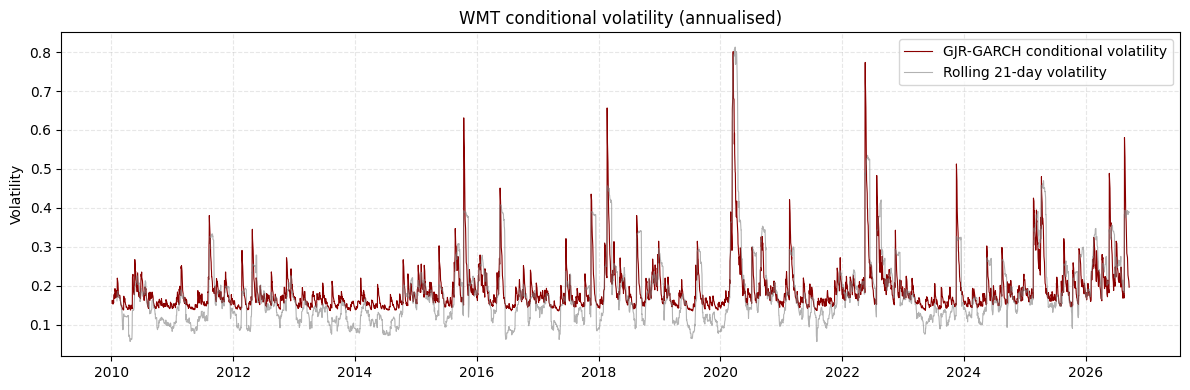

In [18]:
# Conditional volatility estimated by the GJR-GARCH (annualised, in decimals)
res_wmt = models[('WMT', 'Daily', 't')]
cond_vol = res_wmt.conditional_volatility / 100 * np.sqrt(252)

plt.figure(figsize=(12, 4))
plt.plot(cond_vol.index, cond_vol, color='darkred', linewidth=0.8, label='GJR-GARCH conditional volatility')
plt.plot(rolling_vol.index, rolling_vol, color='grey', linewidth=0.8, alpha=0.6, label='Rolling 21-day volatility')
plt.title('WMT conditional volatility (annualised)')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/03_conditional_volatility_wmt.png', dpi=150)
plt.show()

**Reading the results (Fact 5):**

- **Simple correlation:** for WMT, $corr(r_t, |r_{t+1}|)$ is negative and significant at lag 1, but weak at the following lags (only lag 4, at ≈ −0.04, is also slightly outside the band).
  For SPY it is negative and outside the 95% band at all 10 lags → a much stronger leverage effect in the market.
- **WMT daily GJR-GARCH (Student-t):** γ ≈ 0.07 and significant (*p* < 0.01) → negative shocks increase volatility more.
  With normal innovations γ is not significant, so the evidence for WMT is **moderate** and depends on the specification.
- **SPY (daily):** γ ≈ 0.2–0.3 and highly significant, with α ≈ 0 → practically only negative shocks push volatility up.
- **Weekly / monthly (WMT):** γ is not significant. Beware of two "degenerate" models (with no volatility dynamics):
  the weekly one with normal innovations (α = γ = 0 and β ≈ 1) and the monthly one with Student-t (α = γ = 0 and β = 1). In these cases the estimated
  volatility only rises along a straight line over time. With only ~200 monthly observations the monthly GARCH is not very reliable,
  so we do not draw strong conclusions from that frequency (and at the weekly frequency we use the t model).

**Conclusion:** there is a leverage effect in daily WMT returns, but it is weak compared with the index; it is not visible at the lower frequencies.

## 8. Fact 6 — Conditional non-normality (standardised residuals)

The **standardised residuals** are $z_t = \varepsilon_t / \sigma_t$, i.e. each day's shock divided by the volatility predicted by the GARCH.
If the GARCH model with normal innovations were correct, $z_t$ would be normal (0, 1).

We test:
- the normality of $z_t$ (skewness, kurtosis, Jarque-Bera);
- the autocorrelation of $z_t$ and $z_t^2$ (Ljung-Box) → to see whether the GARCH has "cleaned up" the clustering;
- Q-Q plots against the **normal** and against the **Student-t** (with the estimated degrees of freedom).

In [19]:
rows = []
for asset in assets:
    for freq in frequencies.keys():
        for distribution in ['normal', 't']:
            res = models[(asset, freq, distribution)]
            z = res.std_resid.dropna()
            lag = test_lags[freq][1]
            rows.append({
                'Asset': asset,
                'Frequency': freq,
                'Innovations': distribution,
                'z skewness': stats.skew(z),
                'z excess kurtosis': stats.kurtosis(z),
                'z JB p-value': stats.jarque_bera(z).pvalue,
                'LB z p-value': acorr_ljungbox(z, lags=[lag])['lb_pvalue'].iloc[0],
                'LB z² p-value': acorr_ljungbox(z ** 2, lags=[lag])['lb_pvalue'].iloc[0],
            })

tab_residuals = pd.DataFrame(rows).set_index(['Asset', 'Frequency', 'Innovations'])
display(tab_residuals.round(4))

z skewness  z excess kurtosis  z JB p-value  LB z p-value  LB z² p-value
Asset Frequency Innovations                                                                          
WMT   Daily     normal          -0.6435            15.0211        0.0000        0.1280         0.9884
                t               -0.6617            15.6666        0.0000        0.1406         0.9623
      Weekly    normal          -0.7837             4.6164        0.0000        0.1882         0.6585
                t               -0.9945             7.1261        0.0000        0.2968         0.9997
      Monthly   normal          -0.2505             0.5307        0.1098        0.7510         0.8284
                t               -0.3228             0.6633        0.0287        0.7561         0.8850
SPY   Daily     normal          -0.7294             2.6005        0.0000        0.5090         0.5369
                t               -0.7944             3.1670        0.0000        0.3530         0.6615
      Weekly    normal          -0.8441             2.3225        0.0000        0.4483         0.8499
                t               -0.8504             2.3427        0.0000        0.3841         0.8887
      Monthly   normal          -0.7533             0.2611        0.0001        0.6332         0.8340
                t               -0.7752             0.3325        0.0000        0.5989         0.7944

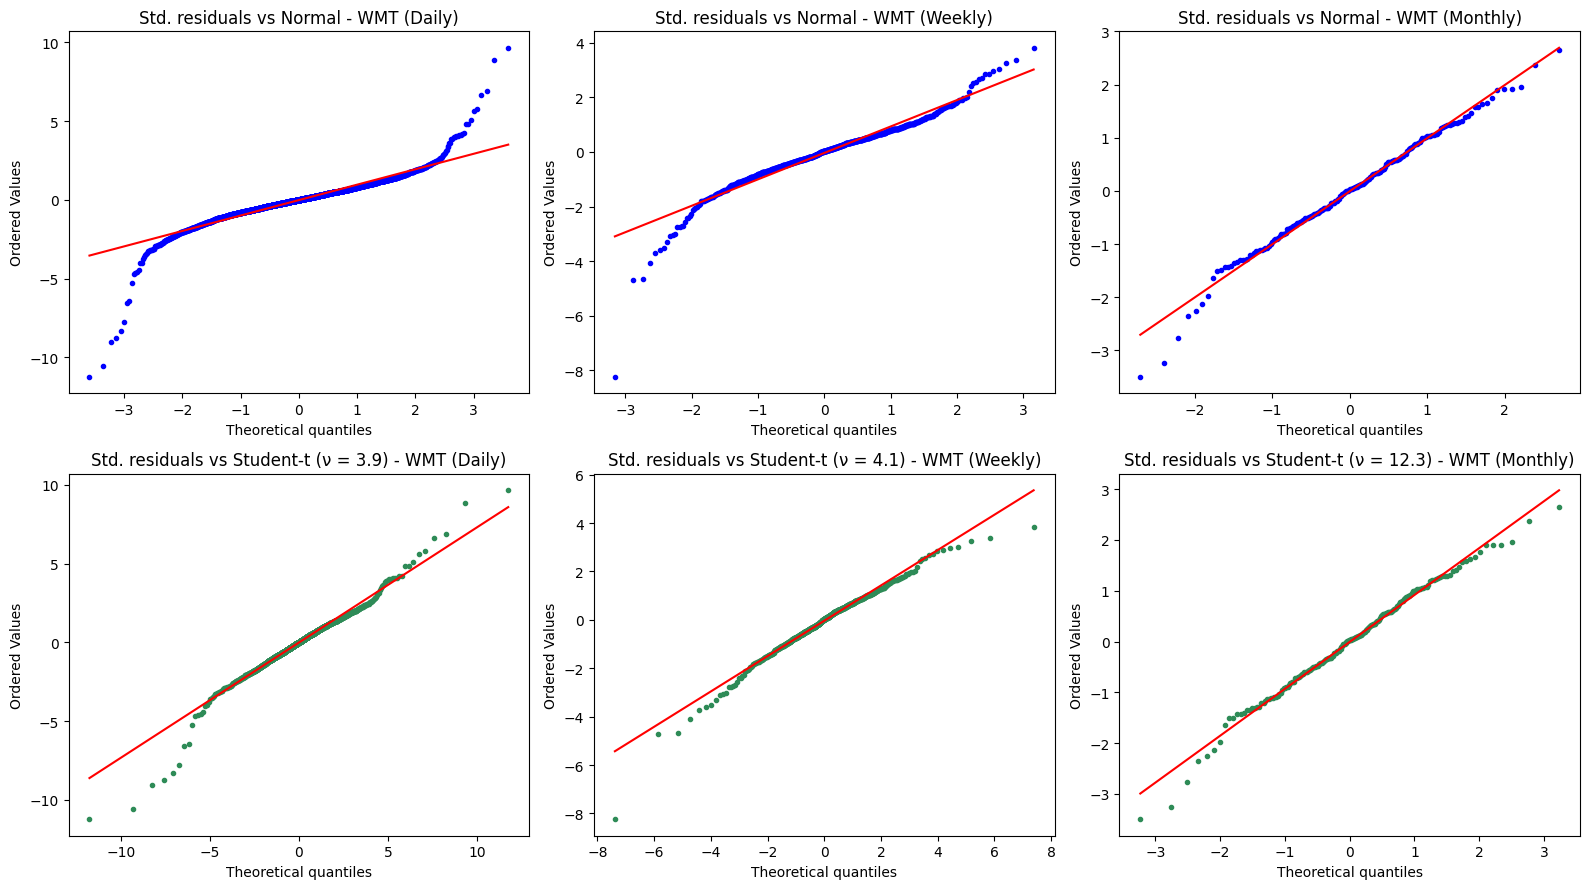

In [20]:
# Q-Q plots of the WMT standardised residuals (Student-t model), at the 3 frequencies
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for j, freq in enumerate(frequencies.keys()):
    res = models[('WMT', freq, 't')]
    z = res.std_resid.dropna()
    nu = res.params['nu']

    # Top row: against the normal
    stats.probplot(z, dist='norm', plot=axes[0, j])
    axes[0, j].get_lines()[0].set_markersize(3)
    axes[0, j].get_lines()[1].set_color('red')
    axes[0, j].set_title(f'Std. residuals vs Normal - WMT ({freq})')

    # Bottom row: against the Student-t with the estimated degrees of freedom
    stats.probplot(z, dist=stats.t, sparams=(nu,), plot=axes[1, j])
    axes[1, j].get_lines()[0].set_markersize(3)
    axes[1, j].get_lines()[0].set_color('seagreen')
    axes[1, j].get_lines()[1].set_color('red')
    axes[1, j].set_title(f'Std. residuals vs Student-t (ν = {nu:.1f}) - WMT ({freq})')

plt.tight_layout()
plt.savefig('../figures/03_qqplot_std_residuals_wmt.png', dpi=150)
plt.show()

In [21]:
# The largest standardised residuals (in absolute value) - on which days did they happen?
res = models[('WMT', 'Daily', 't')]
z = res.std_resid.dropna()

largest = z.abs().sort_values(ascending=False).head(8).index
tab_largest = pd.DataFrame({
    'Log return': ret_d.loc[largest, 'WMT'],
    'Std. residual z': z.loc[largest],
})
tab_largest.index = tab_largest.index.date
display(tab_largest.round(4))

,Log return,Std. residual z
2015-10-14,-0.1058,-11.2400
2022-05-17,-0.1208,-10.5660
2017-11-16,0.1034,9.6584
2026-08-20,-0.0960,-9.0333
2018-08-16,0.0892,8.8612
2023-11-16,-0.0844,-8.7594
2022-07-26,-0.0791,-8.3086
2018-02-20,-0.1074,-7.7712


**Reading the results (Fact 6):**

- After modelling the volatility, the daily standardised residuals of WMT **are still not normal**:
  very high excess kurtosis and Jarque-Bera with *p-value* ≈ 0 → **conditional non-normality**.
- The Q-Q plot against the normal moves far away from the line in the tails; against the Student-t (ν ≈ 4) the fit is much better,
  although the most extreme days still lie off the line.
- The model with Student-t innovations has a much lower AIC than the normal one (table in section 7) → the fat tails matter.
- The Ljung-Box test on $z_t^2$ is **no longer** significant → the GJR-GARCH has captured the volatility clustering well.
  The Ljung-Box test on $z_t$ is not significant either → the small "significant" autocorrelation of Fact 1 disappears
  once we control for volatility.
- The largest residuals coincide with dates in Walmart's quarterly earnings calendar (mid-February, May, August and November)
  or with *guidance* revisions: they are information **jumps** that no GARCH model can anticipate. This is the main reason for the fat tails.
- At the monthly frequency the residuals are already close to normal (excess kurtosis < 1): Jarque-Bera only rejects for the t model (p ≈ 0.03)
  and not for the normal model (p ≈ 0.11). As the monthly GARCH is not very reliable (see Fact 5), the monthly evidence is **weak**.

**Conclusion:** there is clear conditional non-normality at the daily and weekly frequencies; the Student-t is a more suitable choice than the normal.
At the monthly frequency the evidence is weak.

## 9. Summary table of the stylised facts

We build the conclusion for each fact with simple rules (all at 5%):

| Fact | Rule used |
|---|---|
| 1. Little autocorrelation | Ljung-Box (middle lag) does not reject → *Supported*; it rejects but max\|ρ(1..5)\| < 0.10 → *Supported (significant but tiny)*; otherwise → *Not supported* |
| 2. Fat tails / non-normal | JB rejects and excess kurtosis > 0 → *Supported* |
| 3. Negative skewness | skewness < 0 and bootstrap *p* (skew ≥ 0) < 0.05 → *Supported*; otherwise → *Not significant* (the `skewtest` is not used because it assumes normal tails) |
| 4. Volatility clustering | Ljung-Box on \|r\| **and** on r² reject → *Supported*; only one → *Partial*; neither → *Not supported* |
| 5. Leverage effect | γ > 0 and significant in the GJR-GARCH-t → *Supported* |
| 6. Conditional non-normality | JB on the standardised residuals (GJR-GARCH-t) rejects → *Supported* |

In [22]:
rows = []
for asset in assets:
    for freq, table in frequencies.items():
        r = table[asset].dropna()
        lag = test_lags[freq][1]

        # ---- Fact 1: autocorrelation
        p_lb = acorr_ljungbox(r, lags=[lag])['lb_pvalue'].iloc[0]
        max_acf = np.abs(acf(r, nlags=5)[1:]).max()
        if p_lb >= ALPHA:
            conclusion = 'Supported'
        elif max_acf < 0.10:
            conclusion = 'Supported (significant but tiny)'
        else:
            conclusion = 'Not supported'
        rows.append({'Asset': asset, 'Frequency': freq, 'Fact': '1. Little serial correlation',
                     'Statistic': f'max |ACF(1-5)| = {max_acf:.3f}', 'p-value': p_lb, 'Conclusion': conclusion})

        # ---- Fact 2: non-normal / fat tails
        p_jb = stats.jarque_bera(r).pvalue
        kurt = stats.kurtosis(r)
        conclusion = 'Supported' if (p_jb < ALPHA and kurt > 0) else 'Not supported'
        rows.append({'Asset': asset, 'Frequency': freq, 'Fact': '2. Non-normal, fat tails',
                     'Statistic': f'excess kurtosis = {kurt:.2f}', 'p-value': p_jb, 'Conclusion': conclusion})

        # ---- Fact 3: negative skewness
        skewness = stats.skew(r)
        p_skew = tab_skewness.loc[(asset, freq), 'Bootstrap p (skew >= 0)']    # bootstrap from section 5
        conclusion = 'Supported' if (skewness < 0 and p_skew < ALPHA) else 'Not significant'
        rows.append({'Asset': asset, 'Frequency': freq, 'Fact': '3. Negative skewness',
                     'Statistic': f'skewness = {skewness:.3f}', 'p-value': p_skew, 'Conclusion': conclusion})

        # ---- Fact 4: volatility clustering
        p_abs = acorr_ljungbox(r.abs(), lags=[lag])['lb_pvalue'].iloc[0]
        p_sq = acorr_ljungbox(r ** 2, lags=[lag])['lb_pvalue'].iloc[0]
        n_rejections = int(p_abs < ALPHA) + int(p_sq < ALPHA)
        if n_rejections == 2:
            conclusion = 'Supported'
        elif n_rejections == 1:
            conclusion = 'Partial'
        else:
            conclusion = 'Not supported'
        rows.append({'Asset': asset, 'Frequency': freq, 'Fact': '4. Volatility clustering',
                     'Statistic': f'LB |r| p = {p_abs:.3f}', 'p-value': p_sq, 'Conclusion': conclusion})

        # ---- Fact 5: leverage effect (GJR-GARCH with Student-t)
        res = models[(asset, freq, 't')]
        gamma = res.params['gamma[1]']
        p_gamma = res.pvalues['gamma[1]']
        conclusion = 'Supported' if (gamma > 0 and p_gamma < ALPHA) else 'Not significant'
        rows.append({'Asset': asset, 'Frequency': freq, 'Fact': '5. Leverage effect',
                     'Statistic': f'gamma = {gamma:.3f}', 'p-value': p_gamma, 'Conclusion': conclusion})

        # ---- Fact 6: conditional non-normality
        z = res.std_resid.dropna()
        p_jb_z = stats.jarque_bera(z).pvalue
        conclusion = 'Supported' if p_jb_z < ALPHA else 'Not supported'
        rows.append({'Asset': asset, 'Frequency': freq, 'Fact': '6. Conditional non-normality',
                     'Statistic': f'z excess kurtosis = {stats.kurtosis(z):.2f}', 'p-value': p_jb_z, 'Conclusion': conclusion})

tab_summary = pd.DataFrame(rows)
# Note: for fact 4, the 'p-value' column refers to the Ljung-Box test on r² (the one on |r| is in the 'Statistic' column)

# "Wide" version with only the conclusions: facts in the rows, frequencies in the columns
summary_wmt = tab_summary[tab_summary['Asset'] == 'WMT'].pivot(index='Fact', columns='Frequency', values='Conclusion')
summary_wmt = summary_wmt[['Daily', 'Weekly', 'Monthly']]
print('WMT - conclusion by fact and frequency')
display(summary_wmt)

summary_spy = tab_summary[tab_summary['Asset'] == 'SPY'].pivot(index='Fact', columns='Frequency', values='Conclusion')
summary_spy = summary_spy[['Daily', 'Weekly', 'Monthly']]
print('SPY - conclusion by fact and frequency (comparison)')
display(summary_spy)

WMT - conclusion by fact and frequency


Frequency,Daily,Weekly,Monthly
Fact,,,
1. Little serial correlation,Supported (significant but tiny),Supported,Supported
"2. Non-normal, fat tails",Supported,Supported,Supported
3. Negative skewness,Not significant,Supported,Not significant
4. Volatility clustering,Supported,Partial,Not supported
5. Leverage effect,Supported,Not significant,Not significant
6. Conditional non-normality,Supported,Supported,Supported


SPY - conclusion by fact and frequency (comparison)


Frequency,Daily,Weekly,Monthly
Fact,,,
1. Little serial correlation,Not supported,Supported (significant but tiny),Supported
"2. Non-normal, fat tails",Supported,Supported,Supported
3. Negative skewness,Not significant,Supported,Supported
4. Volatility clustering,Supported,Supported,Supported
5. Leverage effect,Supported,Supported,Not significant
6. Conditional non-normality,Supported,Supported,Supported


In [23]:
display(tab_summary.round(4))

,Asset,Frequency,Fact,Statistic,p-value,Conclusion
0,WMT,Daily,1. Little serial correlation,max |ACF(1-5)| = 0.041,0.0011,Supported (significant but tiny)
1,WMT,Daily,"2. Non-normal, fat tails",excess kurtosis = 14.32,0.0000,Supported
2,WMT,Daily,3. Negative skewness,skewness = -0.255,0.2725,Not significant
3,WMT,Daily,4. Volatility clustering,LB |r| p = 0.000,0.0000,Supported
4,WMT,Daily,5. Leverage effect,gamma = 0.071,0.0055,Supported
5,WMT,Daily,6. Conditional non-normality,z excess kurtosis = 15.67,0.0000,Supported
6,WMT,Weekly,1. Little serial correlation,max |ACF(1-5)| = 0.095,0.1406,Supported
7,WMT,Weekly,"2. Non-normal, fat tails",excess kurtosis = 6.67,0.0000,Supported
8,WMT,Weekly,3. Negative skewness,skewness = -0.853,0.0265,Supported
9,WMT,Weekly,4. Volatility clustering,LB |r| p = 0.000,0.1880,Partial


## 10. Appendix — descriptive statistics of every asset (daily, weekly and monthly)

The brief asks for daily, weekly and monthly log returns **for each asset**. They were computed in notebook `01`;
this table summarises them for all 25 series (23 stocks + SPY + ^GSPC), so the report can check whether the patterns
found for WMT (fat tails, excess kurtosis falling at lower frequencies, the sign of the skewness) also appear in the
other assets. The skewness here is only a point estimate (no significance test); for WMT the negative skewness is
significant only at the weekly frequency (section 5).

In [24]:
rows = []
for asset in ret_d.columns:                       # all 25 series in the files
    for freq, table in frequencies.items():
        row = descriptive_stats(table[asset], periods_per_year[freq])
        row['JB p-value'] = stats.jarque_bera(table[asset].dropna()).pvalue   # Jarque-Bera normality test
        row['Asset'] = asset
        row['Frequency'] = freq
        rows.append(row)

tab_all_assets = pd.DataFrame(rows).set_index(['Asset', 'Frequency'])
with pd.option_context('display.max_rows', 100):     # show all 75 rows (pandas shows only 60 by default)
    display(tab_all_assets.round(4))

# Quick summary: in how many of the 25 series is normality rejected at 5%, for each frequency?
rejected = (tab_all_assets['JB p-value'] < ALPHA).groupby(level='Frequency').sum()
print('Series (out of 25) whose normality is rejected by Jarque-Bera at 5%:')
print(rejected[['Daily', 'Weekly', 'Monthly']].to_dict())

N    Mean  Std. dev.     Min     Max  Skewness  Excess kurtosis  Ann. mean  Ann. volatility  JB p-value
Asset Frequency                                                                                                            
NVDA  Daily      4202  0.0015     0.0284 -0.2077  0.2609    0.1729           6.7531     0.3757           0.4515      0.0000
      Weekly      871  0.0072     0.0590 -0.2238  0.2638    0.1686           1.3218     0.3738           0.4252      0.0000
      Monthly     199  0.0324     0.1232 -0.3861  0.4403   -0.1766           0.8613     0.3884           0.4269      0.0275
AAPL  Daily      4202  0.0009     0.0177 -0.1377  0.1426   -0.1700           6.0281     0.2375           0.2811      0.0000
      Weekly      871  0.0046     0.0385 -0.1927  0.1374   -0.3061           1.5355     0.2370           0.2779      0.0000
      Monthly     199  0.0202     0.0750 -0.1999  0.1960   -0.2173          -0.3125     0.2418           0.2599      0.3049
MSFT  Daily      4202  0.0007     0.0164 -0.1595  0.1442   -0.0269           8.7595     0.1839           0.2603      0.0000
      Weekly      871  0.0035     0.0332 -0.1551  0.1968    0.0843           3.1142     0.1837           0.2396      0.0000
      Monthly     199  0.0160     0.0653 -0.1881  0.2198   -0.0663           0.4064     0.1922           0.2261      0.4687
AVGO  Daily      4202  0.0013     0.0241 -0.2221  0.2186   -0.0894           8.3403     0.3358           0.3826      0.0000
      Weekly      871  0.0064     0.0502 -0.2016  0.2249    0.1467           2.3092     0.3333           0.3620      0.0000
      Monthly     199  0.0287     0.0889 -0.2353  0.3606    0.2557           0.9933     0.3447           0.3078      0.0057
AMD   Daily      4202  0.0010     0.0355 -0.2775  0.4206    0.3020           8.7281     0.2432           0.5628      0.0000
      Weekly      871  0.0047     0.0757 -0.2942  0.3905    0.1380           1.9948     0.2438           0.5458      0.0000
      Monthly     199  0.0208     0.1623 -0.5285  0.5554    0.0080           0.7966     0.2499           0.5621      0.0719
MU    Daily      4202  0.0011     0.0319 -0.2209  0.2106   -0.0808           4.0155     0.2737           0.5064      0.0000
      Weekly      871  0.0052     0.0672 -0.3110  0.3202   -0.2082           1.5110     0.2711           0.4846      0.0000
      Monthly     199  0.0237     0.1382 -0.3937  0.6300    0.2891           1.7394     0.2849           0.4787      0.0000
BRK-B Daily      4202  0.0005     0.0121 -0.1008  0.1098   -0.0315           9.5122     0.1224           0.1922      0.0000
      Weekly      871  0.0023     0.0250 -0.1440  0.0932   -0.2000           2.6071     0.1217           0.1803      0.0000
      Monthly     199  0.0095     0.0473 -0.1461  0.1256   -0.0920          -0.0556     0.1137           0.1637      0.8581
JPM   Daily      4202  0.0006     0.0172 -0.1621  0.1656   -0.1150           9.4270     0.1511           0.2738      0.0000
      Weekly      871  0.0028     0.0364 -0.2187  0.2010   -0.3591           3.5883     0.1479           0.2622      0.0000
      Monthly     199  0.0132     0.0716 -0.2597  0.1950   -0.6547           1.5512     0.1588           0.2481      0.0000
V     Daily      4202  0.0007     0.0156 -0.1456  0.1397   -0.0938           9.8791     0.1761           0.2475      0.0000
      Weekly      871  0.0034     0.0312 -0.1813  0.1815   -0.2592           4.8893     0.1761           0.2248      0.0000
      Monthly     199  0.0153     0.0556 -0.2178  0.1537   -0.4261           0.9360     0.1832           0.1927      0.0013
LLY   Daily      4202  0.0009     0.0167 -0.1524  0.1457    0.3564          11.2061     0.2338           0.2655      0.0000
      Weekly      871  0.0045     0.0362 -0.1976  0.1615   -0.0750           2.7739     0.2341           0.2611      0.0000
      Monthly     199  0.0197     0.0670 -0.1957  0.2217    0.1138           0.6250     0.2363           0.2321      0.1597
JNJ   Daily      4202  0.0005     0.0108 -0.1058  0.

Series (out of 25) whose normality is rejected by Jarque-Bera at 5%:
{'Daily': 25, 'Weekly': 25, 'Monthly': 15}


## 11. Save the tables (CSV + Excel)

All the tables go to `../results/`. The Excel file has one sheet per table, so that they are easy to copy into the report.

In [25]:
tables = {
    'descriptive_stats': tab_descriptive,
    'ljung_box_returns': tab_lb_returns,
    'acf_lags_1_5': tab_acf,
    'normality': tab_normality,
    'skewness': tab_skewness,
    'vol_clustering': tab_clustering,
    'leverage_correlation': tab_leverage_simple,
    'gjr_garch': tab_gjr,
    'std_residuals': tab_residuals,
    'largest_residuals': tab_largest,
    'facts_summary': tab_summary,
    'facts_summary_wmt': summary_wmt,
    'descriptive_stats_all_assets': tab_all_assets,
}

# Note (Windows): close the .xlsx/.csv files in Excel before running this cell,
# otherwise Excel locks them and you get a "PermissionError".
with pd.ExcelWriter('../results/03_stylised_facts.xlsx') as excel:
    for name, table in tables.items():
        table.to_excel(excel, sheet_name=name[:31])         # Excel accepts at most 31 characters in a sheet name
        table.to_csv(f'../results/03_{name}.csv', encoding='utf-8-sig')   # 'utf-8-sig' -> Excel displays σ, γ, ² correctly

print('Tables saved in ../results/')

Tables saved in ../results/


## Overall conclusion (for the report)

Walmart was chosen because it is a **defensive** stock, for which we would expect, a priori, "well-behaved" returns.
Even so, at the daily frequency almost all the stylised facts hold: practically zero autocorrelation, very fat tails,
strong volatility clustering, a (moderate) leverage effect and non-normality even after modelling the volatility.
The exception is **asymmetry**: the skewness is negative, but it is only statistically significant (and only just) at the weekly frequency
(at the daily frequency it depends on a few quarterly earnings days, and the classic `skewtest` overstates the evidence because of the fat tails).
When we move to the monthly frequency, most of these effects weaken (the distribution gets closer to the normal and the clustering disappears),
which shows that **the conclusions depend on the frequency** used. By comparison, SPY shows a stronger leverage effect and stronger clustering.

**Implication for portfolio construction:** using only the mean and the variance (as in Markowitz) ignores fat tails and asymmetry,
and volatility is not constant over time. This justifies (i) re-estimating the parameters with a rolling window and
(ii) also looking at tail/drawdown risk measures (Sortino, Calmar, Sterling, maximum drawdown) in the backtest of the following notebook (`04`).